# Research Extension

## Baseline Results

In [1]:
import numpy as np
import heapq
from matplotlib.colors import ListedColormap
import matplotlib.pyplot as plt
import torch
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

# Variables to indicate features of the environment
OPEN = 0
OBSTACLE = 1
POS = 2
GOAL = 3
SUBGOAL = 4
PATH = 5

# Dummy variable to feed to the model during training
DUMMY = 6

In [9]:
class DisjointSet:
    def __init__(self, elements):
        self.num_comps = len(elements)
        self.parent = {}
        for element in elements:
            self.parent[element] = element

    def add(self, element):
        self.parent[element] = element
        self.num_comps += 1

    def find(self, element):
        if element not in self.parent:
            self.add(element)
            return element
        
        while self.parent[self.parent[element]] != self.parent[element]:
            self.parent[element] = self.find(self.parent[element])
        return self.parent[element]

    def merge(self, element1, element2):
            self.parent[self.parent[element2]] = self.parent[element1]
            self.num_comps -= 1

    def same_set(self, element1, element2):
        return self.find(element1) == self.find(element2)
    
    def print_sets(self):
        print(self.parent)

def in_range(pos, r, c, dim):
    if pos[0] + r < 0 or pos[1] + c < 0:
        return False
    if pos[0] + r >= dim or pos[1] + c >= dim:
        return False
    return True

def maze_neighbors(node, dim):
    neighbors = []
    if node[0] > 0:
        neighbors.append((node[0] - 1, node[1]))
    if node[0] < dim - 1:
        neighbors.append((node[0] + 1, node[1]))
    if node[1] > 0:
        neighbors.append((node[0], node[1] - 1))
    if node[1] < dim - 1:
        neighbors.append((node[0], node[1] + 1))
    return neighbors

def generate_connections(dim):
    coords = []
    for r in range(dim):
        for c in range(dim):
            coords.append((r, c))
    maze = DisjointSet(coords)
    connections = []
    while maze.num_comps > 1:
        start = coords[np.random.randint(0, dim**2)]
        neighbors = maze_neighbors(start, dim)
        end = neighbors[np.random.randint(0, len(neighbors))]
        if not maze.same_set(start, end):
            maze.merge(start, end)
            connections.append((start, end))

    return connections

def find_visible(pos, range, maze):
    visible = []
    for r in np.arange(-1*range, range + 1, 1):
        for c in np.arange(-1*range, range + 1, 1):
            if in_range(pos, r, c, maze.shape[0]):
                visible.append((pos[0] + r, pos[1] + c))

    return visible

def find_visible_subgoals(maze, dist):
    subgoals = []
    for r in range(len(maze)):
        for c in range(len(maze)):
            # Check if node is reachable
            if dist[r, c] < np.inf:
                if maze[r, c, 1] == GOAL:
                    subgoals.append((r, c))
                else:
                    # Iterate over neighbors
                    for i, j in [(0, 1), (0, -1), (1, 0), (-1, 0)]:
                            if maze[i + r, j + c, 1] == DUMMY:
                                subgoals.append((r, c))
                                break
    return subgoals

def visible_neighbors(maze, pos):
    n = []
    r, c = pos
    for i in [-1, 0, 1]:
        for j in [-1, 0, 1]:
            in_bounds = i + r >= 0 and j + c >= 0 and i + r < maze.shape[0] and j + c < maze.shape[1]
            not_center = not (i == 0 and j == 0)
            not_obstacle = in_bounds and maze[i + r, j + c] != OBSTACLE
            cardinal = i == 0 or j == 0
            visible = maze[i + r, j + c] != DUMMY
            if not_center and not_obstacle and in_bounds and cardinal and visible:
                n.append((i + r, j + c))

    return n

def visible_dijkstra(maze, pos):
    pq = []
    dist = np.ones(shape=maze.shape) * np.inf
    prev = np.full((*maze.shape, 2), (-1, -1), dtype="object")
    for r in range(maze.shape[0]):
        for c in range(maze.shape[1]):
            node = (r, c)
            if node == pos:
                dist[node] = 0
                heapq.heappush(pq, (dist[node], node))
            
            if maze[node] == 0:
                heapq.heappush(pq, (dist[node], node))

    while len(pq) > 0:
        d, node = heapq.heappop(pq)
        for n in visible_neighbors(maze, node):
            alt = dist[node] + 1
            if alt < dist[n]:
                dist[n] = alt
                prev[n] = (node)
                heapq.heappush(pq, (alt, n))
    
    return dist, prev

In [10]:
def sub_heuristic(subgoal, goal, dist):
    return np.abs(subgoal[0] - goal[0]) + np.abs(subgoal[1] - goal[1]) + dist[subgoal]

def path_to(start, goal, prev):
    path = [goal]
    parent = prev[goal]
    while parent[0] != start[0] or parent[1] != start[1]:
        path.insert(0, parent)
        parent = prev[parent[0], parent[1]]
    path.insert(0, parent)
    path = [tuple(map(int, p)) for p in path]
    return path

def optimistic_plan(maze, pos, goal, plan_path):
    if pos == goal:
        return maze, plan_path, 1
    
    visible = find_visible(pos, 3, maze)

    for node in visible:
        maze[node[0], node[1], 1] = maze[node[0], node[1], 0]
    
    dist, prev = visible_dijkstra(maze[:, :, 1], pos)

    # Optimistically find the best subgoal
    subgoals = find_visible_subgoals(maze, dist)
    if len(subgoals) == 0:
        return maze, plan_path, 0
    sorted_subgoals = sorted(subgoals, key=lambda sg: sub_heuristic(sg, goal, dist))
    best_subgoal = sorted_subgoals[0]

    # Classically navigate to the subgoal
    path = path_to(pos, best_subgoal, prev)
    plan_path.extend(path)

    maze[best_subgoal[0], best_subgoal[1]] = (POS, POS)
    maze[pos[0], pos[1]] = (OPEN, OPEN)
    pos = best_subgoal

    return optimistic_plan(maze, pos, goal, plan_path)

In [11]:
def get_neighbors(node):
    neighbors = []
    for r in [-1, 0, 1]:
        for c in [-1, 0, 1]:
            if r == 0 and c == 0:
                continue
            neighbors.append((node[0] + r, node[1] + c))
    
    return neighbors

def gen_guided_maze(maze, pos, goal):
    dist, prev = visible_dijkstra(maze[:, :, 0], pos)
    path = path_to(pos, goal, prev)

    guided_maze = maze.copy()

    for step in path:
        neighbors = get_neighbors(step)
        for neighbor in neighbors:
            if maze[neighbor[0], neighbor[1], 0] == OBSTACLE:
                guided_maze[neighbor[0], neighbor[1], 0] = OPEN

    return guided_maze

def gen_anti_maze(maze, pos, goal):
    dist, prev = visible_dijkstra(maze[:, :, 0], pos)
    path = path_to(pos, goal, prev)

    anti_maze = maze.copy()

    for r in range(maze.shape[0]):
        for c in range(maze.shape[1]):
            if (r, c) not in path and maze[r, c, 0] == OPEN:
                neighbors = get_neighbors((r, c))
                for neighbor in neighbors:
                    if maze[neighbor[0], neighbor[1], 0] == OBSTACLE:
                        anti_maze[neighbor[0], neighbor[1], 0] = OPEN

    return anti_maze

def generate_mazes(dim):
    connections = generate_connections(dim)

    maze = np.ones(shape=(6*dim + 1, 6*dim + 1, 2)) * OBSTACLE
    maze[:, :, 1] = np.ones(shape=(maze.shape[0], maze.shape[1])) * DUMMY
    for r in range(dim):
        for c in range(dim):
            maze[6*r + 3, 6*c + 3, 0] = OPEN

    for connection in connections:
        node1, node2 = connection
        if node1[0] == node2[0]:
            col_dif = node2[1] - node1[1]
            maze[6*node1[0] + 3, 6*node1[1] + 3 + col_dif, 0] = OPEN
            maze[6*node1[0] + 3, 6*node1[1] + 3 + 2*col_dif, 0] = OPEN
            maze[6*node1[0] + 3, 6*node1[1] + 3 + 3*col_dif, 0] = OPEN
            maze[6*node1[0] + 3, 6*node1[1] + 3 + 4*col_dif, 0] = OPEN
            maze[6*node1[0] + 3, 6*node1[1] + 3 + 5*col_dif, 0] = OPEN
        else:
            row_dif = node2[0] - node1[0]
            maze[6*node1[0] + 3 + row_dif, 6*node1[1] + 3, 0] = OPEN
            maze[6*node1[0] + 3 + 2*row_dif, 6*node1[1] + 3, 0] = OPEN
            maze[6*node1[0] + 3 + 3*row_dif, 6*node1[1] + 3, 0] = OPEN
            maze[6*node1[0] + 3 + 4*row_dif, 6*node1[1] + 3, 0] = OPEN
            maze[6*node1[0] + 3 + 5*row_dif, 6*node1[1] + 3, 0] = OPEN

    pos = (6*np.random.randint(0, dim) + 3, 6*np.random.randint(0, dim) + 3)
    goal = (6*np.random.randint(0, dim) + 3, 6*np.random.randint(0, dim) + 3)
    while pos == goal:
        goal = (6*np.random.randint(0, dim) + 3, 6*np.random.randint(0, dim) + 3)

    maze[pos[0], pos[1]] = (POS, POS)
    maze[goal[0], goal[1]] = (GOAL, GOAL)

    guided_maze = gen_guided_maze(maze, pos, goal)
    anti_maze = gen_anti_maze(maze, pos, goal)
    
    return maze, guided_maze, anti_maze, pos, goal

In [15]:
def find_labels(maze, goal, subgoal):
    # Random for now, but will become based on the optimistic planner
    _, plan, success = optimistic_plan(maze, subgoal, goal, [])

    if success == 1:
        return 1, len(plan), 0
    return 0, 0, 2*len(plan)

def get_window(maze, pad, pos):
    maze_padded = np.pad(
        maze,
        pad_width=((pad, pad), (pad, pad), (0, 0)),
        mode='constant',
        constant_values=7,
    )

    px, py = pos
    px += pad
    py += pad

    maze_window = maze_padded[px - pad : px + pad + 1, py - pad : py + pad + 1, 1]
    return maze_window.flatten()

def prevent_backtrack(maze, pos, subgoal):
    row_dif = pos[0] - subgoal[0]
    col_dif = pos[1] - subgoal[1]

    # Prevent the search from backtracking
    if row_dif < 0:
        maze[subgoal[0] - 1, subgoal[1]] = (OBSTACLE, OBSTACLE)
        maze[subgoal[0] - 1, subgoal[1] - 1] = (OBSTACLE, OBSTACLE)
        maze[subgoal[0] - 1, subgoal[1] + 1] = (OBSTACLE, OBSTACLE)
        maze[subgoal[0] - 1, subgoal[1] - 2] = (OBSTACLE, OBSTACLE)
        maze[subgoal[0] - 1, subgoal[1] + 2] = (OBSTACLE, OBSTACLE)
    elif row_dif > 0:
        maze[subgoal[0] + 1, subgoal[1]] = (OBSTACLE, OBSTACLE)
        maze[subgoal[0] + 1, subgoal[1] - 1] = (OBSTACLE, OBSTACLE)
        maze[subgoal[0] + 1, subgoal[1] + 1] = (OBSTACLE, OBSTACLE)
        maze[subgoal[0] + 1, subgoal[1] - 2] = (OBSTACLE, OBSTACLE)
        maze[subgoal[0] + 1, subgoal[1] + 2] = (OBSTACLE, OBSTACLE)

    if col_dif < 0:
        maze[subgoal[0], subgoal[1] - 1] = (OBSTACLE, OBSTACLE)
        maze[subgoal[0] - 1, subgoal[1] - 1] = (OBSTACLE, OBSTACLE)
        maze[subgoal[0] + 1, subgoal[1] - 1] = (OBSTACLE, OBSTACLE)
        maze[subgoal[0] - 2, subgoal[1] - 1] = (OBSTACLE, OBSTACLE)
        maze[subgoal[0] + 2, subgoal[1] - 1] = (OBSTACLE, OBSTACLE)
    elif col_dif > 0:
        maze[subgoal[0], subgoal[1] + 1] = (OBSTACLE, OBSTACLE)
        maze[subgoal[0] - 1, subgoal[1] + 1] = (OBSTACLE, OBSTACLE)
        maze[subgoal[0] + 1, subgoal[1] + 1] = (OBSTACLE, OBSTACLE)
        maze[subgoal[0] - 2, subgoal[1] + 1] = (OBSTACLE, OBSTACLE)
        maze[subgoal[0] + 2, subgoal[1] + 1] = (OBSTACLE, OBSTACLE)

    return maze

def optimistic_samples(maze, pos, goal, x: list, y: list):
    if pos == goal:
        x.append(np.hstack((get_window(maze, 4, pos), pos, goal, goal)))
        y.append((1, 0, 0))
        return x, y
    
    visible = find_visible(pos, 3, maze)

    for node in visible:
        maze[node[0], node[1], 1] = maze[node[0], node[1], 0]
    
    dist, _ = visible_dijkstra(maze[:, :, 1], pos)

    subgoals = find_visible_subgoals(maze, dist)

    for subgoal in subgoals:
        subgoal_maze = maze.copy()

        x.append(np.hstack((get_window(subgoal_maze, 4, pos), pos, goal, subgoal)))

        subgoal_maze[pos[0], pos[1]] = (OPEN, OPEN)
        subgoal_maze[subgoal[0], subgoal[1]] = (POS, POS)

        subgoal_maze = prevent_backtrack(subgoal_maze, pos, subgoal)

        y.append(find_labels(subgoal_maze.copy(), goal, subgoal))

    if len(subgoals) == 0:
        x.append(np.hstack((get_window(maze, 4, pos), pos, goal, pos)))
        y.append((1, 0, 0))
        return x, y
    
    # Optimistically find the best subgoal
    sorted_subgoals = sorted(subgoals, key=lambda sg: sub_heuristic(sg, goal, dist))
    best_subgoal = sorted_subgoals[0]

    maze[best_subgoal[0], best_subgoal[1]] = (POS, POS)
    maze[pos[0], pos[1]] = (OPEN, OPEN)
    pos = best_subgoal

    return optimistic_samples(maze, pos, goal, x, y)


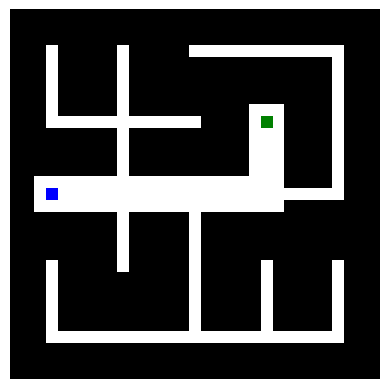

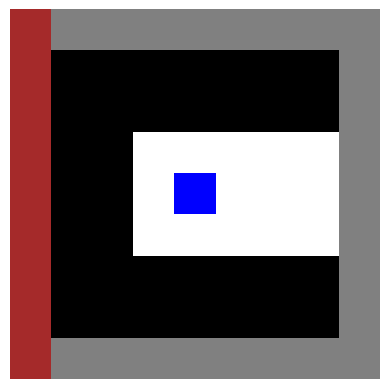

[15.  3.  9. 21. 14.  6.]
(1, 91, 0)


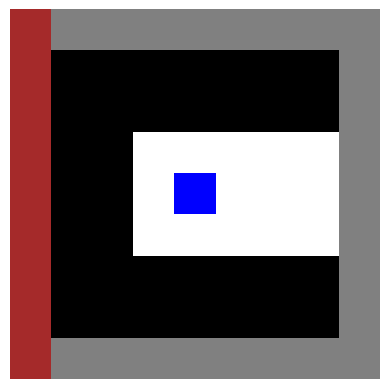

[15.  3.  9. 21. 15.  6.]
(1, 94, 0)


In [35]:
from matplotlib.colors import ListedColormap, BoundaryNorm

_, maze, _, pos, goal = generate_mazes(5)

maze_cmap = ListedColormap(['white', 'black', 'blue', 'green'])
training_cmap = ListedColormap(['white', 'black', 'blue', 'green', 'purple', 'grey'])
plt.imshow(maze[:, :, 0], maze_cmap)
plt.axis(False)
plt.show()

x, y = optimistic_samples(maze, pos, goal, [], [])

values = [0, 1, 2, 3, 4, 5, 6, 7]
colors = ['white', 'black', 'blue', 'green', 'purple', 'orange', 'grey', 'brown']
cmap = ListedColormap(colors)
norm = BoundaryNorm(values + [values[-1] + 1], cmap.N)

for sample in range(2):
    plt.imshow(np.array(x[sample][:-6]).reshape(9, 9), cmap=cmap, norm=norm)
    plt.axis(False)
    plt.show()

    print(x[sample][81:])
    print(y[sample])

In [19]:
def generate_samples(dim, num_samples, maze_type):
    x = []
    y = []
    
    count = 0
    while len(x) < num_samples:
        gen = generate_mazes(dim)
        maze = gen[maze_type]
        pos = gen[3]
        goal = gen[4]
        
        print(f"New maze {count}, {len(x)} samples")
        sample_x, sample_y = optimistic_samples(maze, pos, goal, [], [])
        x.extend(sample_x)
        y.extend(sample_y)
        count += 1

    return torch.tensor((x[:num_samples]), dtype=torch.float32), torch.tensor((y[:num_samples]), dtype=torch.float32)

In [20]:
x, y = generate_samples(5, 50000, 2)

plt.imshow(np.array(x[0][:-6]).reshape(9, 9), cmap=cmap, norm=norm)
plt.axis(False)
plt.show()

New maze 0, 0 samples


/var/folders/g_/2b49jtkd7xz5v300df9n742w0000gn/T/ipykernel_69650/2147353427.py:18: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /Users/runner/work/_temp/anaconda/conda-bld/pytorch_1729647065806/work/torch/csrc/utils/tensor_new.cpp:281.)
  return torch.tensor((x[:num_samples]), dtype=torch.float32), torch.tensor((y[:num_samples]), dtype=torch.float32)


In [329]:
torch.save(x, "../data/x.pt")
torch.save(y, "../data/y.pt")

In [23]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class FCN(nn.Module):
    def __init__(self, inSize):
        super().__init__()
        self.inSize = inSize

        self.lin1 = nn.Linear(inSize, 256)
        self.lin2 = nn.Linear(256, 128)
        self.lin3 = nn.Linear(128, 64)
        self.lin4 = nn.Linear(64, 32)
        self.lin5 = nn.Linear(32, 16)

        self.bn1 = nn.BatchNorm1d(256)
        self.bn2 = nn.BatchNorm1d(128)
        self.bn3 = nn.BatchNorm1d(64)
        self.bn4 = nn.BatchNorm1d(32)

        self.drop = nn.Dropout(0.5)
        self.sig = nn.Sigmoid()

        self.out_class = nn.Linear(16, 1)
        self.out_reg = nn.Linear(16, 2)

    def forward(self, x):
        x = self.drop(self.sig(self.bn1(self.lin1(x))))
        x = self.drop(self.sig(self.bn2(self.lin2(x))))
        x = self.drop(self.sig(self.bn3(self.lin3(x))))
        x = self.drop(self.sig(self.bn4(self.lin4(x))))

        class_out = self.sig(self.out_class(self.lin5(x)))
        reg_out = self.out_reg(self.lin5(x))

        return class_out, reg_out

    def compute_loss(self, class_pred, reg_pred, class_target, reg_target, class_weight=1.0, reg_weight=1.0):
        bce_loss = F.binary_cross_entropy(class_pred, class_target)

        ct = class_target.view(-1)

        cost_goal_pred = reg_pred[:, 0]
        cost_explore_pred = reg_pred[:, 1]

        cost_goal_target = reg_target[:, 0]
        cost_explore_target = reg_target[:, 1]

        selected_pred = torch.where(ct > 0.5, cost_goal_pred, cost_explore_pred)
        selected_tgt  = torch.where(ct > 0.5, cost_goal_target, cost_explore_target)

        mse_loss = F.mse_loss(selected_pred, selected_tgt)

        total_loss = class_weight * bce_loss + reg_weight * mse_loss
        return total_loss

In [24]:
def train_model(num_epochs, x_path, y_path):
    x = torch.load(f"../data/{x_path}.pt", weights_only=True)
    y = torch.load(f"../data/{y_path}.pt", weights_only=True)

    model = FCN(inSize=len(x[0]))
    optimizer = optim.Adam(model.parameters(), lr=1e-3)

    dataset = TensorDataset(x, y)
    loader = DataLoader(dataset, batch_size=256, shuffle=True)

    best_loss = np.inf
    stale = 0
    early_stop = 5

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0

        for batch_x, batch_y in loader:

            class_pred, reg_pred = model(batch_x)

            loss = model.compute_loss(class_pred, reg_pred, batch_y[:, 0:1], batch_y[:, 1:], reg_weight=0.0)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        avg_loss = running_loss / len(loader)
        print(f"Epoch [{epoch+1}/{num_epochs}] | Loss: {avg_loss:.4f}")

        if avg_loss < best_loss:
            best_loss = avg_loss
            stale = 0
        else:
            stale += 1

        if stale >= early_stop:
            break

    return model


In [25]:
model = train_model(5, "5x5_guided_x", "5x5_guided_y")

Epoch [1/5] | Loss: 0.6914
Epoch [2/5] | Loss: 0.6871
Epoch [3/5] | Loss: 0.6848
Epoch [4/5] | Loss: 0.6800
Epoch [5/5] | Loss: 0.6700


In [331]:
torch.save(model.state_dict(), "../models/model.pth")

In [26]:
def learned_plan(maze, pos, goal, plan_path, model):
    if pos == goal:
        return maze, plan_path
    
    visible = find_visible(pos, 3, maze)

    for node in visible:
        maze[node[0], node[1], 1] = maze[node[0], node[1], 0]
    
    dist, prev = visible_dijkstra(maze[:, :, 1], pos)

    # Find the best subgoal based on the learned model
    subgoals = find_visible_subgoals(maze, dist)
    best_subgoal = subgoals[0]
    best_q = np.inf

    for subgoal in subgoals:
        x = np.hstack((get_window(maze, 4, pos), pos, goal, subgoal))
        x = torch.tensor(x, dtype=torch.float32).unsqueeze(0)
        p, cost = model(x)

        r_term = np.inf
        # One step recursion term for faster implementation
        for sub in subgoals:
            if sub != subgoal:
                sub_x = np.hstack((get_window(maze, 4, pos), pos, goal, sub))
                sub_x = torch.tensor(sub_x, dtype=torch.float32).unsqueeze(0)
                sub_p, sub_cost = model(sub_x)
                r_term = torch.minimum(torch.tensor(r_term), dist[sub] + sub_p * sub_cost[:, 0] + (1 - sub_p) * sub_cost[:, 1]).item()

        q = dist[subgoal] + p * cost[:, 0] + (1 - p) * (cost[:, 1] + r_term)

        if q < best_q:
            best_q = q
            best_subgoal = subgoal

    # Classically navigate to the subgoal
    path = path_to(pos, best_subgoal, prev)
    plan_path.extend(path)

    maze[best_subgoal[0], best_subgoal[1]] = (POS, POS)
    maze[pos[0], pos[1]] = (OPEN, OPEN)
    pos = best_subgoal

    return learned_plan(maze, pos, goal, plan_path, model)

In [27]:
def solve_mazes(dim, num_mazes, x_path, model_path):
    x = torch.load(f"../data/{x_path}.pt", weights_only=True)
    guided_model = FCN(inSize=len(x[0]))
    guided_model.load_state_dict(torch.load(f"../models/{model_path}.pth", weights_only=True))
    guided_model.eval()

    opt_cost = []
    base_cost = []
    guided_cost = []
    anti_cost = []

    for _ in range(num_mazes):
        maze, guided_maze, anti_maze, pos, goal = generate_mazes(dim)

        opt_maze = maze.copy()
        opt_maze, opt_plan, _ = optimistic_plan(opt_maze, pos, goal, [])
        opt_cost.append(len(opt_plan))

        mod_maze = maze.copy()
        mod_maze, mod_plan = learned_plan(mod_maze, pos, goal, [], guided_model)
        base_cost.append(len(mod_plan))

        mod_maze = guided_maze.copy()
        mod_maze, mod_plan = learned_plan(mod_maze, pos, goal, [], guided_model)
        guided_cost.append(len(mod_plan))

        mod_maze = anti_maze.copy()
        mod_maze, mod_plan = learned_plan(mod_maze, pos, goal, [], guided_model)
        anti_cost.append(len(mod_plan))

    return opt_cost, base_cost, guided_cost, anti_cost

In [28]:
def plot_comparison(x_axis, y_axis, title="Path Length Comparison", x_label="X Axis", y_label="Y Axis"):
    smooth = np.linspace(0, np.max([np.max(x_axis), np.max(y_axis)]), 500)
    x = np.array(x_axis)
    y = np.array(y_axis)

    x_greater = x > y
    y_greater = y > x
    equal = y == x

    plt.figure()
    plt.title(title)
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.scatter(x[x_greater], y[x_greater])
    plt.scatter(x[y_greater], y[y_greater])
    plt.scatter(x[equal], y[equal])
    plt.plot(smooth, smooth)
    plt.show()

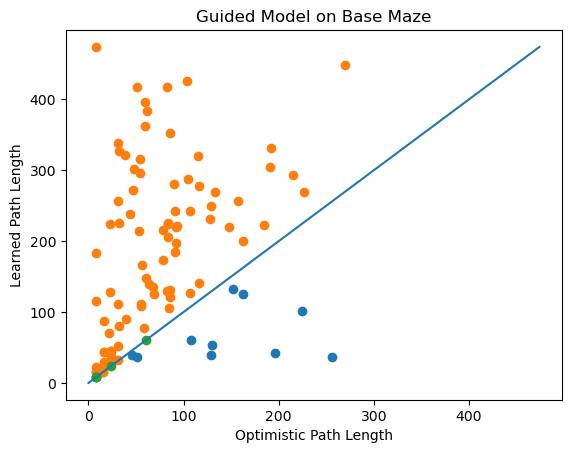

2.268836965082699


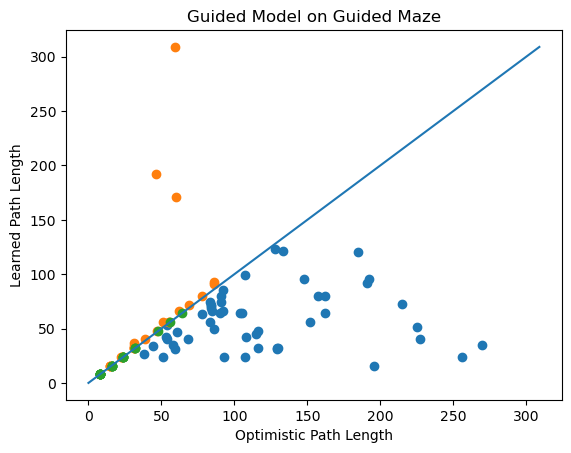

0.6720924127067471


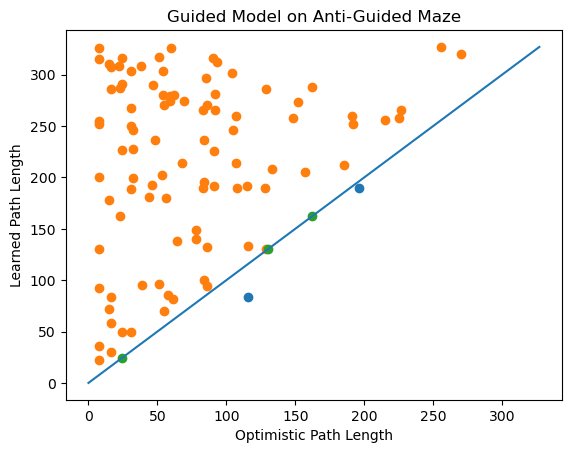

2.767393016539774


In [111]:
opt_cost, base_cost, guided_cost, anti_cost = solve_mazes(5, 100, "5x5_guided_x", "5x5_guided_noreg")

plot_comparison(opt_cost, base_cost, "Guided Model on Base Maze", "Optimistic Path Length", "Learned Path Length")
print(np.sum(base_cost) / np.sum(opt_cost))
plot_comparison(opt_cost, guided_cost, "Guided Model on Guided Maze", "Optimistic Path Length", "Learned Path Length")
print(np.sum(guided_cost) / np.sum(opt_cost))
plot_comparison(opt_cost, anti_cost, "Guided Model on Anti-Guided Maze", "Optimistic Path Length", "Learned Path Length")
print(np.sum(anti_cost) / np.sum(opt_cost))

Optimistic planning


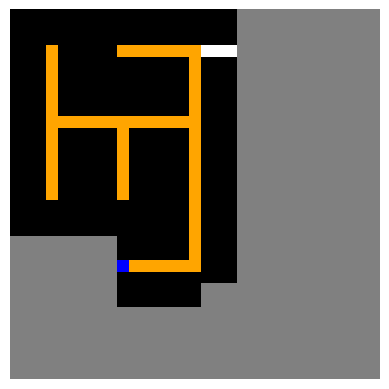

Model on base maze:


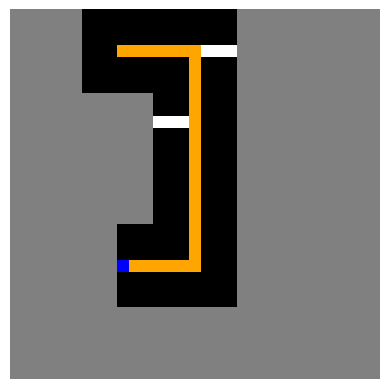

Model on guided maze:


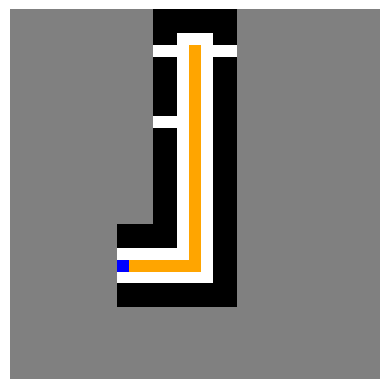

Model on anti guided maze


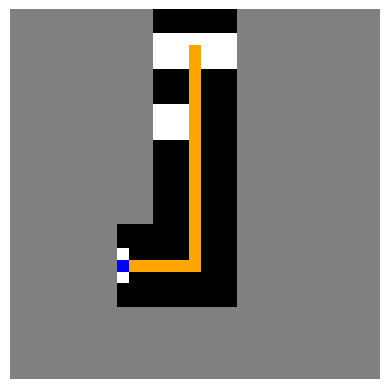

In [105]:
maze, guided_maze, anti_maze, pos, goal = generate_mazes(5)

opt_maze = maze.copy()
opt_maze, plan, _ = optimistic_plan(opt_maze, pos, goal, [])

for step in plan[:-1]:
    opt_maze[step[0], step[1]] = (PATH, PATH)

print("Optimistic planning")

path_cmap = ListedColormap(['white', 'black', 'blue', 'green', 'purple', 'orange', 'gray'])

plt.imshow(opt_maze[:, :, 1], path_cmap)
plt.axis(False)
plt.show()

x = torch.load("../data/5x5_hybrid_x.pt", weights_only=True)
model = FCN(inSize=len(x[0]))
model.load_state_dict(torch.load("../models/5x5_hybrid_noreg.pth", weights_only=True))
model.eval()

mod_maze = maze.copy()
mod_maze, plan = learned_plan(mod_maze, pos, goal, [], model)

for step in plan[:-1]:
    mod_maze[step[0], step[1]] = (PATH, PATH)

print("Model on base maze:")

plt.imshow(mod_maze[:, :, 1], path_cmap)
plt.axis(False)
plt.show()

mod_guided = guided_maze.copy()
mod_guided, plan = learned_plan(mod_guided, pos, goal, [], model)

for step in plan[:-1]:
    mod_guided[step[0], step[1]] = (PATH, PATH)

print("Model on guided maze:")

plt.imshow(mod_guided[:, :, 1], path_cmap)
plt.axis(False)
plt.show()

mod_anti = anti_maze.copy()
mod_anti, plan = learned_plan(mod_anti, pos, goal, [], model)

for step in plan[:-1]:
    mod_anti[step[0], step[1]] = (PATH, PATH)

print("Model on anti guided maze")

plt.imshow(mod_anti[:, :, 1], path_cmap)
plt.axis(False)
plt.show()

## Anti-Guided Model Training

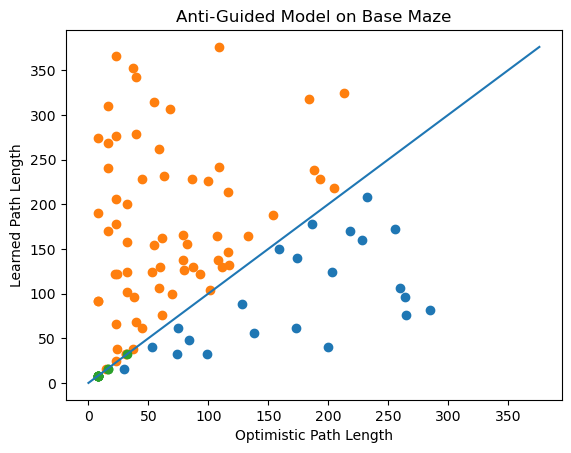

1.6764389134857005


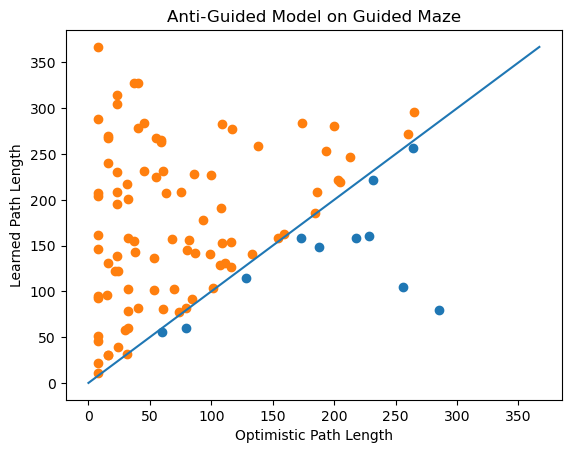

2.0512145506760797


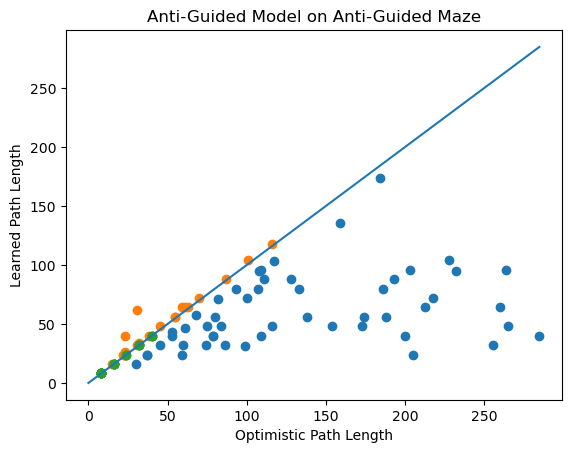

0.5644369989230585


In [110]:
opt_cost, base_cost, guided_cost, anti_cost = solve_mazes(5, 100, "5x5_anti_x", "5x5_anti_noreg")

plot_comparison(opt_cost, base_cost, "Anti-Guided Model on Base Maze", "Optimistic Path Length", "Learned Path Length")
print(np.sum(base_cost) / np.sum(opt_cost))
plot_comparison(opt_cost, guided_cost, "Anti-Guided Model on Guided Maze", "Optimistic Path Length", "Learned Path Length")
print(np.sum(guided_cost) / np.sum(opt_cost))
plot_comparison(opt_cost, anti_cost, "Anti-Guided Model on Anti-Guided Maze", "Optimistic Path Length", "Learned Path Length")
print(np.sum(anti_cost) / np.sum(opt_cost))

In [386]:
guided_x = torch.load("../data/5x5_guided_x.pt", weights_only=True)
guided_y = torch.load("../data/5x5_guided_y.pt", weights_only=True)

anti_x = torch.load("../data/5x5_anti_x.pt", weights_only=True)
anti_y = torch.load("../data/5x5_anti_y.pt", weights_only=True)

guided_x = guided_x[:guided_x.size(0)//2]
guided_y = guided_y[:guided_y.size(0)//2]

anti_x = anti_x[:anti_x.size(0)//2]
anti_y = anti_y[:anti_y.size(0)//2]

x = torch.cat((guided_x, anti_x), dim=0)
y = torch.cat((guided_y, anti_y), dim=0)

torch.save(x, "../data/5x5_hybrid_x.pt")
torch.save(y, "../data/5x5_hybrid_y.pt")

In [387]:
model = train_model(100, "5x5_hybrid_x", "5x5_hybrid_y")

Epoch [1/100] | Loss: 0.6734
Epoch [2/100] | Loss: 0.6694
Epoch [3/100] | Loss: 0.6673
Epoch [4/100] | Loss: 0.6664
Epoch [5/100] | Loss: 0.6650
Epoch [6/100] | Loss: 0.6644
Epoch [7/100] | Loss: 0.6630
Epoch [8/100] | Loss: 0.6605
Epoch [9/100] | Loss: 0.6563
Epoch [10/100] | Loss: 0.6490
Epoch [11/100] | Loss: 0.6428
Epoch [12/100] | Loss: 0.6354
Epoch [13/100] | Loss: 0.6312
Epoch [14/100] | Loss: 0.6267
Epoch [15/100] | Loss: 0.6238
Epoch [16/100] | Loss: 0.6202
Epoch [17/100] | Loss: 0.6205
Epoch [18/100] | Loss: 0.6156
Epoch [19/100] | Loss: 0.6171
Epoch [20/100] | Loss: 0.6128
Epoch [21/100] | Loss: 0.6120
Epoch [22/100] | Loss: 0.6100
Epoch [23/100] | Loss: 0.6082
Epoch [24/100] | Loss: 0.6058
Epoch [25/100] | Loss: 0.6054
Epoch [26/100] | Loss: 0.6028
Epoch [27/100] | Loss: 0.6024
Epoch [28/100] | Loss: 0.5989
Epoch [29/100] | Loss: 0.5977
Epoch [30/100] | Loss: 0.5939
Epoch [31/100] | Loss: 0.5930
Epoch [32/100] | Loss: 0.5948
Epoch [33/100] | Loss: 0.5910
Epoch [34/100] | Lo

In [388]:
torch.save(model.state_dict(), "../models/5x5_hybrid_noreg.pth")

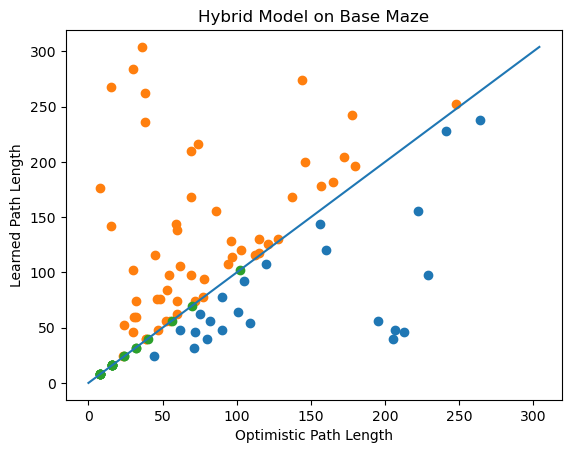

1.2316341829085458


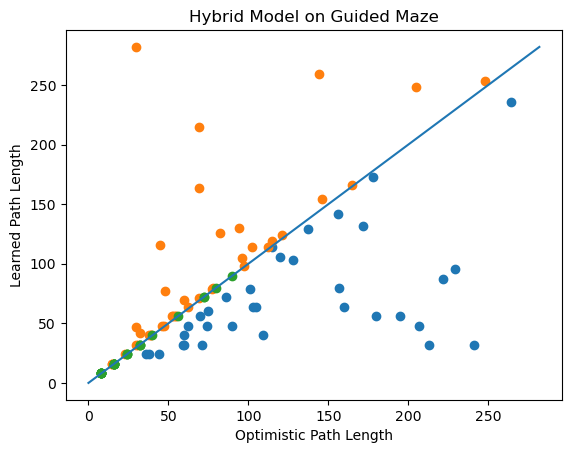

0.8875562218890555


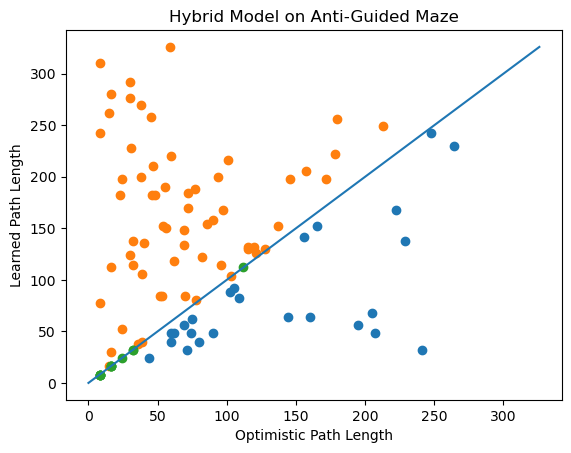

1.580584707646177


In [109]:
opt_cost, base_cost, guided_cost, anti_cost = solve_mazes(5, 100, "5x5_hybrid_x", "5x5_hybrid_noreg")

plot_comparison(opt_cost, base_cost, "Hybrid Model on Base Maze", "Optimistic Path Length", "Learned Path Length")
print(np.sum(base_cost) / np.sum(opt_cost))
plot_comparison(opt_cost, guided_cost, "Hybrid Model on Guided Maze", "Optimistic Path Length", "Learned Path Length")
print(np.sum(guided_cost) / np.sum(opt_cost))
plot_comparison(opt_cost, anti_cost, "Hybrid Model on Anti-Guided Maze", "Optimistic Path Length", "Learned Path Length")
print(np.sum(anti_cost) / np.sum(opt_cost))

## Model Shift

In [39]:
def generate_similarity_samples(dim, num_samples):
    x = []
    y = []
    
    while len(x) < num_samples:
        maze, guided_maze, anti_maze, pos, _ = generate_mazes(dim)

        visible = find_visible(pos, 3, maze)

        for node in visible:
            maze[node[0], node[1], 1] = maze[node[0], node[1], 0]
            guided_maze[node[0], node[1], 1] = guided_maze[node[0], node[1], 0]
            anti_maze[node[0], node[1], 1] = anti_maze[node[0], node[1], 0]
        
        x.extend([get_window(maze, 4, pos).flatten(),
                  get_window(guided_maze, 4, pos).flatten(),
                  get_window(anti_maze, 4, pos).flatten()])
        y.extend([0, 1, 0])

    return torch.tensor((x[:num_samples]), dtype=torch.float32), torch.tensor((y[:num_samples]), dtype=torch.float32)

In [32]:
x, y = generate_similarity_samples(5, 5000)

In [414]:
torch.save(x, "../data/5x5_similarity_x.pt")
torch.save(y, "../data/5x5_similarity_y.pt")

In [40]:
class FCNC(nn.Module):
    def __init__(self, inSize):
        super().__init__()
        self.inSize = inSize

        self.lin1 = nn.Linear(inSize, 128)
        self.lin2 = nn.Linear(128, 64)
        self.lin3 = nn.Linear(64, 32)
        self.lin4 = nn.Linear(32, 16)

        self.bn1 = nn.BatchNorm1d(128)
        self.bn2 = nn.BatchNorm1d(64)
        self.bn3 = nn.BatchNorm1d(32)

        self.drop = nn.Dropout(0.5)
        self.sig = nn.Sigmoid()

        self.out_class = nn.Linear(16, 1)

    def forward(self, x):
        x = self.drop(self.sig(self.bn1(self.lin1(x))))
        x = self.drop(self.sig(self.bn2(self.lin2(x))))
        x = self.drop(self.sig(self.bn3(self.lin3(x))))

        class_out = self.sig(self.out_class(self.lin4(x)))

        return class_out

    def compute_loss(self, class_pred, class_target):
        class_pred = class_pred.view(-1)
        bce_loss = F.binary_cross_entropy(class_pred, class_target)
        return bce_loss

In [41]:
def train_similarity_model(num_epochs, x_path, y_path):
    x = torch.load(f"../data/{x_path}.pt", weights_only=True)
    y = torch.load(f"../data/{y_path}.pt", weights_only=True)

    model = FCNC(inSize=len(x[0]))
    optimizer = optim.Adam(model.parameters(), lr=1e-3)

    dataset = TensorDataset(x, y)
    loader = DataLoader(dataset, batch_size=256, shuffle=True)

    best_loss = np.inf
    stale = 0
    early_stop = 5

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0

        for batch_x, batch_y in loader:

            class_pred = model(batch_x)

            loss = model.compute_loss(class_pred, batch_y[:])

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        avg_loss = running_loss / len(loader)
        print(f"Epoch [{epoch+1}/{num_epochs}] | Loss: {avg_loss:.4f}")

        if avg_loss < best_loss:
            best_loss = avg_loss
            stale = 0
        else:
            stale += 1

        if stale >= early_stop:
            break

    return model

In [422]:
model = train_similarity_model(20, "5x5_similarity_x", "5x5_similarity_y")

Epoch [1/20] | Loss: 0.6571
Epoch [2/20] | Loss: 0.5751
Epoch [3/20] | Loss: 0.4909
Epoch [4/20] | Loss: 0.3737
Epoch [5/20] | Loss: 0.2600
Epoch [6/20] | Loss: 0.1797
Epoch [7/20] | Loss: 0.1408
Epoch [8/20] | Loss: 0.1087
Epoch [9/20] | Loss: 0.0886
Epoch [10/20] | Loss: 0.0723
Epoch [11/20] | Loss: 0.0658
Epoch [12/20] | Loss: 0.0600
Epoch [13/20] | Loss: 0.0517
Epoch [14/20] | Loss: 0.0551
Epoch [15/20] | Loss: 0.0430
Epoch [16/20] | Loss: 0.0413
Epoch [17/20] | Loss: 0.0363
Epoch [18/20] | Loss: 0.0350
Epoch [19/20] | Loss: 0.0390
Epoch [20/20] | Loss: 0.0264


In [423]:
torch.save(model.state_dict(), "../models/5x5_similarity.pth")

In [42]:
def get_similarity(maze, pos, x_path, model_path):
    x = torch.load(f"../data/{x_path}.pt", weights_only=True)
    model = FCNC(inSize=len(x[0]))
    model.load_state_dict(torch.load(f"../models/{model_path}.pth", weights_only=True))
    model.eval()

    result = model(torch.tensor(get_window(maze, 4, pos).flatten(), dtype=torch.float32).unsqueeze(0))

    return result.item()

In [444]:
maze, guided_maze, anti_maze, pos, _ = generate_mazes(5)

visible = find_visible(pos, 3, maze)

for node in visible:
    maze[node[0], node[1], 1] = maze[node[0], node[1], 0]
    guided_maze[node[0], node[1], 1] = guided_maze[node[0], node[1], 0]
    anti_maze[node[0], node[1], 1] = anti_maze[node[0], node[1], 0]

print(get_similarity(maze, pos, "5x5_similarity_x", "5x5_similarity"))
print(get_similarity(guided_maze, pos, "5x5_similarity_x", "5x5_similarity"))
print(get_similarity(anti_maze, pos, "5x5_similarity_x", "5x5_similarity"))

3.201046274625696e-05
0.989185094833374
8.984944543044548e-06


In [43]:
def adaptable_learned_plan(maze, pos, goal, plan_path, model, confidence):
    if pos == goal:
        return maze, plan_path
    
    visible = find_visible(pos, 3, maze)

    for node in visible:
        maze[node[0], node[1], 1] = maze[node[0], node[1], 0]
    
    dist, prev = visible_dijkstra(maze[:, :, 1], pos)

    
    subgoals = find_visible_subgoals(maze, dist)
    if len(subgoals) == 0:
            return maze, plan_path, 0

    if np.random.rand() < confidence:
        best_subgoal = subgoals[0]
        best_q = np.inf


        for subgoal in subgoals:
            x = np.hstack((get_window(maze, 4, pos), pos, goal, subgoal))
            x = torch.tensor(x, dtype=torch.float32).unsqueeze(0)
            p, cost = model(x)

            r_term = np.inf
            # One step recursion term for faster implementation
            for sub in subgoals:
                if sub != subgoal:
                    sub_x = np.hstack((get_window(maze, 4, pos), pos, goal, sub))
                    sub_x = torch.tensor(sub_x, dtype=torch.float32).unsqueeze(0)
                    sub_p, sub_cost = model(sub_x)
                    r_term = torch.minimum(torch.tensor(r_term), dist[sub] + sub_p * sub_cost[:, 0] + (1 - sub_p) * sub_cost[:, 1]).item()

            q = dist[subgoal] + p * cost[:, 0] + (1 - p) * (cost[:, 1] + r_term)

            if q < best_q:
                best_q = q
                best_subgoal = subgoal
    else:
        sorted_subgoals = sorted(subgoals, key=lambda sg: sub_heuristic(sg, goal, dist))
        best_subgoal = sorted_subgoals[0]

    # Classically navigate to the subgoal
    path = path_to(pos, best_subgoal, prev)
    plan_path.extend(path)

    maze[best_subgoal[0], best_subgoal[1]] = (POS, POS)
    maze[pos[0], pos[1]] = (OPEN, OPEN)
    pos = best_subgoal

    return adaptable_learned_plan(maze, pos, goal, plan_path, model, confidence)

Optimistic planning


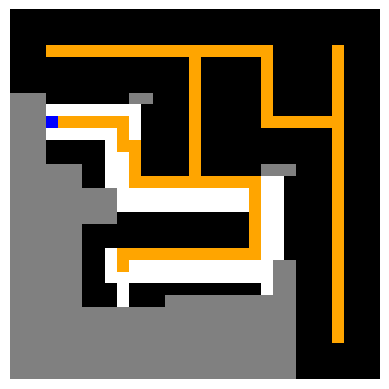

0.9904125332832336
Confidence Model on guided maze:


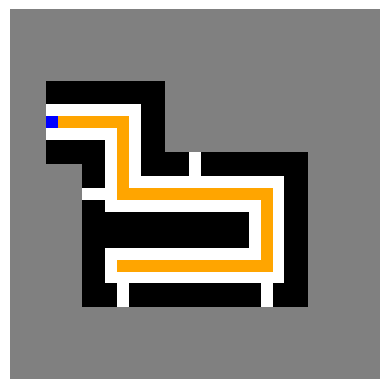

Guided Model on guided maze:


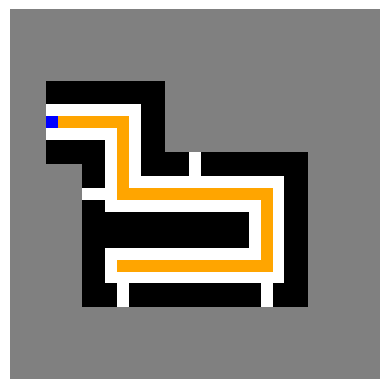

4.321337473811582e-05
Confidence Model on anti guided maze


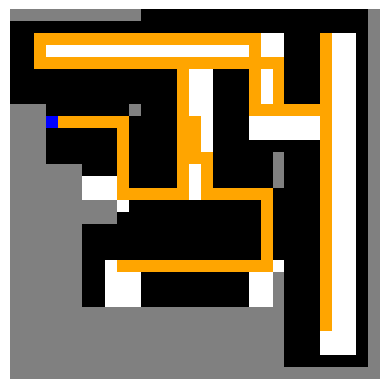

Guided Model on anti guided maze


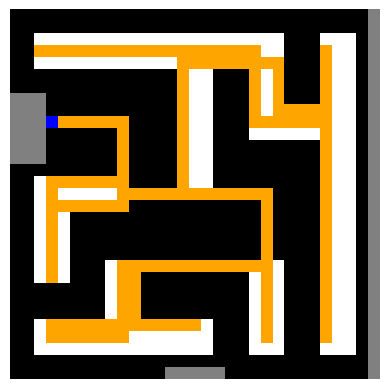

Hybrid Model on guided maze


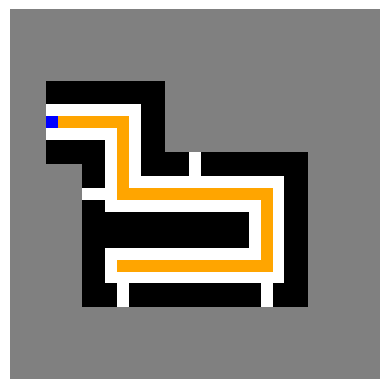

In [93]:
maze, guided_maze, anti_maze, pos, goal = generate_mazes(5)

visible = find_visible(pos, 3, maze)

for node in visible:
    maze[node[0], node[1], 1] = maze[node[0], node[1], 0]
    guided_maze[node[0], node[1], 1] = guided_maze[node[0], node[1], 0]
    anti_maze[node[0], node[1], 1] = anti_maze[node[0], node[1], 0]

opt_maze = guided_maze.copy()
opt_maze, plan, _ = optimistic_plan(opt_maze, pos, goal, [])

for step in plan[:-1]:
    opt_maze[step[0], step[1]] = (PATH, PATH)

print("Optimistic planning")

path_cmap = ListedColormap(['white', 'black', 'blue', 'green', 'purple', 'orange', 'gray'])

plt.imshow(opt_maze[:, :, 1], path_cmap)
plt.axis(False)
plt.show()

x = torch.load("../data/5x5_guided_x.pt", weights_only=True)
model = FCN(inSize=len(x[0]))
model.load_state_dict(torch.load("../models/5x5_guided_noreg.pth", weights_only=True))
model.eval()

mod_maze = guided_maze.copy()
confidence = get_similarity(mod_maze, pos, "5x5_similarity_x", "5x5_similarity")
print(confidence)
mod_maze, plan = adaptable_learned_plan(mod_maze, pos, goal, [], model, confidence)

for step in plan[:-1]:
    mod_maze[step[0], step[1]] = (PATH, PATH)

print("Confidence Model on guided maze:")

plt.imshow(mod_maze[:, :, 1], path_cmap)
plt.axis(False)
plt.show()

mod_maze = guided_maze.copy()
mod_maze, plan = adaptable_learned_plan(mod_maze, pos, goal, [], model, 1)

for step in plan[:-1]:
    mod_maze[step[0], step[1]] = (PATH, PATH)

print("Guided Model on guided maze:")

plt.imshow(mod_maze[:, :, 1], path_cmap)
plt.axis(False)
plt.show()

mod_anti = anti_maze.copy()
confidence = get_similarity(mod_anti, pos, "5x5_similarity_x", "5x5_similarity")
print(confidence)
mod_anti, plan = adaptable_learned_plan(mod_anti, pos, goal, [], model, confidence)

for step in plan[:-1]:
    mod_anti[step[0], step[1]] = (PATH, PATH)

print("Confidence Model on anti guided maze")

plt.imshow(mod_anti[:, :, 1], path_cmap)
plt.axis(False)
plt.show()

mod_anti = anti_maze.copy()
mod_anti, plan = adaptable_learned_plan(mod_anti, pos, goal, [], model, 1)

for step in plan[:-1]:
    mod_anti[step[0], step[1]] = (PATH, PATH)

print("Guided Model on anti guided maze")

plt.imshow(mod_anti[:, :, 1], path_cmap)
plt.axis(False)
plt.show()

x = torch.load("../data/5x5_hybrid_x.pt", weights_only=True)
model = FCN(inSize=len(x[0]))
model.load_state_dict(torch.load("../models/5x5_hybrid_noreg.pth", weights_only=True))
model.eval()

mod_guided = guided_maze.copy()
mod_guided, plan = adaptable_learned_plan(mod_guided, pos, goal, [], model, 1)

for step in plan[:-1]:
    mod_guided[step[0], step[1]] = (PATH, PATH)

print("Hybrid Model on guided maze")

plt.imshow(mod_guided[:, :, 1], path_cmap)
plt.axis(False)
plt.show()

In [107]:
def solve_similarity_mazes(dim, num_mazes, maze_x_path, maze_model_path, sim_x_path, sim_model_path):
    # Load models
    maze_x = torch.load(f"../data/{maze_x_path}.pt", weights_only=True)
    maze_model = FCN(inSize=len(maze_x[0]))
    maze_model.load_state_dict(torch.load(f"../models/{maze_model_path}.pth", weights_only=True))
    maze_model.eval()

    sim_x = torch.load(f"../data/{sim_x_path}.pt", weights_only=True)
    sim_model = FCNC(inSize=len(sim_x[0]))
    sim_model.load_state_dict(torch.load(f"../models/{sim_model_path}.pth", weights_only=True))
    sim_model.eval()

    opt_cost = []
    base_cost = []
    guided_cost = []
    anti_cost = []

    for _ in range(num_mazes):
        # Generate maze
        maze, guided_maze, anti_maze, pos, goal = generate_mazes(dim)

        # Reveal visible nodes
        visible = find_visible(pos, 3, maze)

        for node in visible:
            maze[node[0], node[1], 1] = maze[node[0], node[1], 0]
            guided_maze[node[0], node[1], 1] = guided_maze[node[0], node[1], 0]
            anti_maze[node[0], node[1], 1] = anti_maze[node[0], node[1], 0]

        # Calculate confidence values
        maze_confidence = get_similarity(maze, pos, sim_x_path, sim_model_path)
        guided_confidence = get_similarity(guided_maze, pos, sim_x_path, sim_model_path)
        anti_confidence = get_similarity(anti_maze, pos, sim_x_path, sim_model_path)

        opt_maze = maze.copy()
        opt_maze, opt_plan, _ = optimistic_plan(opt_maze, pos, goal, [])
        opt_cost.append(len(opt_plan))

        mod_maze = maze.copy()
        mod_maze, mod_plan = adaptable_learned_plan(mod_maze, pos, goal, [], maze_model, maze_confidence)
        base_cost.append(len(mod_plan))

        mod_maze = guided_maze.copy()
        mod_maze, mod_plan = adaptable_learned_plan(mod_maze, pos, goal, [], maze_model, guided_confidence)
        guided_cost.append(len(mod_plan))

        mod_maze = anti_maze.copy()
        mod_maze, mod_plan = adaptable_learned_plan(mod_maze, pos, goal, [], maze_model, anti_confidence)
        anti_cost.append(len(mod_plan))

    return opt_cost, base_cost, guided_cost, anti_cost

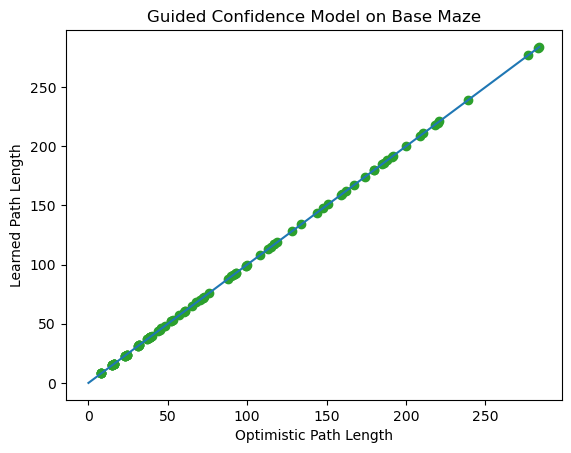

1.0


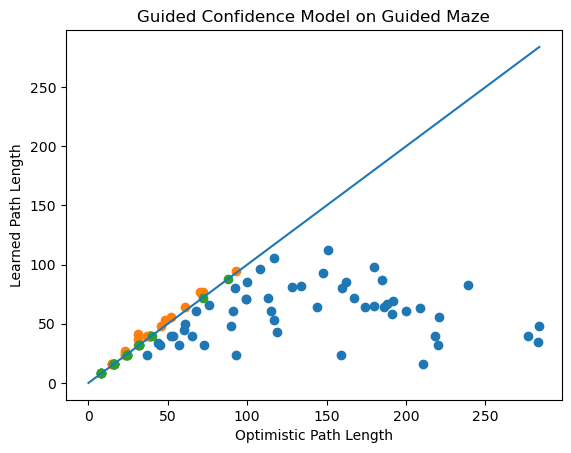

0.5368997376525607


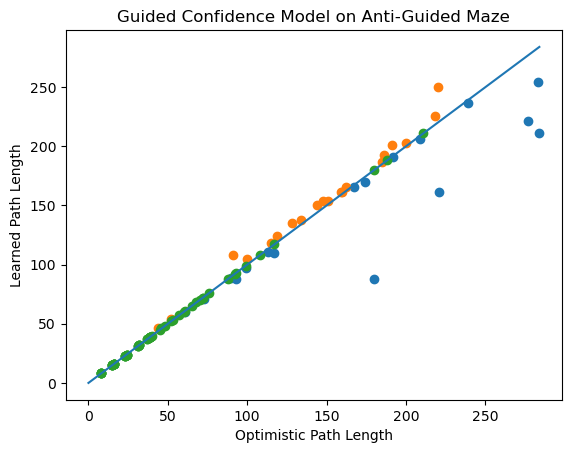

0.975590281738337


In [112]:
opt_cost, base_cost, guided_cost, anti_cost = solve_similarity_mazes(5, 100, "5x5_guided_x", "5x5_guided_noreg", "5x5_similarity_x", "5x5_similarity")

plot_comparison(opt_cost, base_cost, "Guided Confidence Model on Base Maze", "Optimistic Path Length", "Learned Path Length")
print(np.sum(base_cost) / np.sum(opt_cost))
plot_comparison(opt_cost, guided_cost, "Guided Confidence Model on Guided Maze", "Optimistic Path Length", "Learned Path Length")
print(np.sum(guided_cost) / np.sum(opt_cost))
plot_comparison(opt_cost, anti_cost, "Guided Confidence Model on Anti-Guided Maze", "Optimistic Path Length", "Learned Path Length")
print(np.sum(anti_cost) / np.sum(opt_cost))

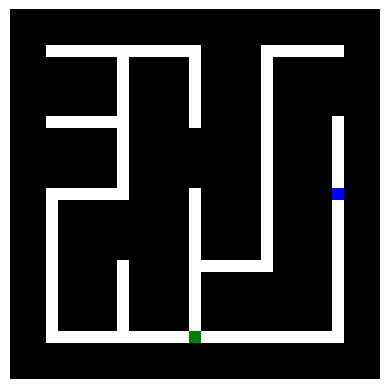

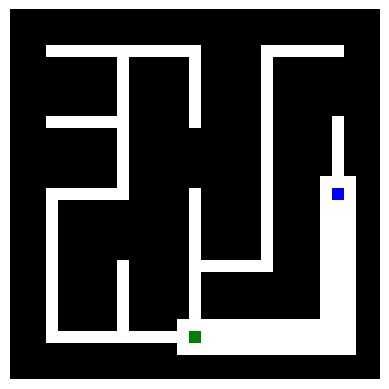

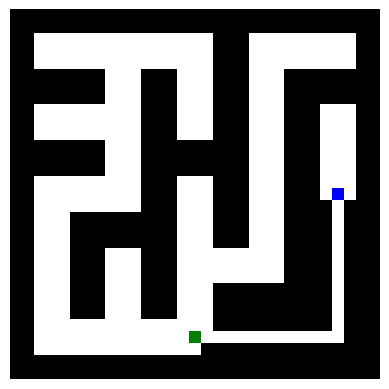

In [37]:
maze, guided_maze, anti_maze, pos, goal = generate_mazes(5)

maze_cmap = ListedColormap(['white', 'black', 'blue', 'green'])

plt.imshow(maze[:, :, 0], maze_cmap)
plt.axis(False)
plt.show()

plt.imshow(guided_maze[:, :, 0], maze_cmap)
plt.axis(False)
plt.show()

plt.imshow(anti_maze[:, :, 0], maze_cmap)
plt.axis(False)
plt.show()